# Partie 2 - Classification CLAIM , REF vs CONTEXT


## Installation des dépendances
Installation de la bibliothèque `optuna` pour la recherche d'hyperparamètres.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.3 MB/s eta 0:00:00


## Imports
Importation de toutes les bibliothèques nécessaires : `pandas`, `numpy` pour la manipulation des données, `matplotlib`, `seaborn` pour la visualisation, `sklearn` pour les modèles et l'évaluation, `optuna` pour l'optimisation des hyperparamètres.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import re
import string
import numpy as np

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import learning_curve, cross_val_score, KFold, ShuffleSplit
from sklearn.metrics import f1_score, make_scorer
from sklearn.utils.multiclass import unique_labels
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
import nltk
from nltk.corpus import wordnet
from wordcloud import WordCloud
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.patches as mpatches


## Téléchargement des ressources NLTK
Téléchargement des ressources nécessaires pour la tokenisation (`punkt`), la lemmatisation (`wordnet`) et les mots vides (`stopwords`).

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


## **Vérifications du dataframe**



In [ ]:
def MyCleanText(X,
                 lowercase=False,
                 removestopwords=False,
                 removedigit=False,
                 getstemmer=False,
                 getlemmatisation=False
                 ):

    sentence = str(X)
    sentence = re.sub(r'[^\w\s]',' ', sentence)
    sentence = re.sub(r'\s+[a-zA-Z]\s+', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence, flags=re.I)
    tokens = word_tokenize(sentence)

    if lowercase:
        tokens = [token.lower() for token in tokens]
    table = str.maketrans('', '', string.punctuation)
    words = [token.translate(table) for token in tokens]
    words = [word for word in words if word.isalnum()]


    if removedigit:
        words = [word for word in words if not word.isdigit()]

    if removestopwords:
        words = [word for word in words if not word in stop_words]

    if getlemmatisation:
        lemmatizer = WordNetLemmatizer()
        words = [lemmatizer.lemmatize(word) for word in words]

    if getstemmer:
        ps = PorterStemmer()
        words = [ps.stem(word) for word in words]
    sentence = ' '.join(words)
    return sentence


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r"[^\w\s]", "", text)
    return text.strip()


class TextNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self,
                 removestopwords=False,
                 lowercase=False,
                 removedigit=False,
                 getstemmer=False,
                 getlemmatisation=False
                ):

        self.lowercase=lowercase
        self.getstemmer=getstemmer
        self.removestopwords=removestopwords
        self.getlemmatisation=getlemmatisation
        self.removedigit=removedigit

    def transform(self, X, **transform_params):
        X=X.copy()
        return [MyCleanText(text,lowercase=self.lowercase,
                            getstemmer=self.getstemmer,
                            removestopwords=self.removestopwords,
                            getlemmatisation=self.getlemmatisation,
                            removedigit=self.removedigit) for text in X]

    def fit(self, X, y=None, **fit_params):
        return self

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X).transform(X)

    def get_params(self, deep=True):
        return {
            'lowercase':self.lowercase,
            'getstemmer':self.getstemmer,
            'removestopwords':self.removestopwords,
            'getlemmatisation':self.getlemmatisation,
            'removedigit':self.removedigit
        }

    def set_params (self, **parameters):
        for parameter, value in parameters.items():
            setattr(self,parameter,value)
        return self


def plot_learning_curves(estimator, X, y, title):
    is_vectorized = not isinstance(X.iloc[0], str) if isinstance(X, pd.Series) else hasattr(X, "shape")

    if not is_vectorized:
        pipeline = make_pipeline(TfidfVectorizer(), estimator)
    else:
        pipeline = make_pipeline(estimator)

    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X, y,
        cv=StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=0),
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 20),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    val_avg = np.mean(test_mean)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Score entraînement')
    plt.plot(train_sizes, test_mean, 'o-', color='green', label='Score validation')

    plt.title(f"Courbe d’apprentissage : {title}\nAccuracy moy. validation = {val_avg:.3f}", fontsize=12)
    plt.xlabel("Taille de l'ensemble d'entraînement")
    plt.ylabel("Exactitude")
    plt.legend(loc='best')
    plt.grid()
    plt.tight_layout()
    plt.show()



def objective(trial, model_name, X, y):
    classes = unique_labels(y)
    if len(classes) != 2:
        raise ValueError(f"Classification binaire requise, trouvé : {classes}")
    pos_label = classes[1]
    scorer = make_scorer(f1_score, pos_label=pos_label)

    if model_name == "Naive Bayes":
        alpha = trial.suggest_float("alpha", 0.3, 1.0)
        model = MultinomialNB(alpha=alpha)

    elif model_name == "SVM":
        C = trial.suggest_float('C', 0.05, 0.25, log=True)
        model = SVC(C=C, kernel='linear', gamma='scale', class_weight='balanced')

    elif model_name == "Random Forest":
        n_estimators = trial.suggest_int("n_estimators", 50, 150, step=50)
        max_depth = trial.suggest_int("max_depth", 4, 12)
        min_samples_split = trial.suggest_int("min_samples_split", 4, 10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 6)

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    elif model_name == "Logistic Regression":
        C = trial.suggest_float("C", 0.05, 0.3, log=True)
        model = LogisticRegression(
            C=C,
            penalty='l2',
            solver='liblinear',
            class_weight='balanced',
            max_iter=1000
        )

    elif model_name == "Gradient Boosting":
        n_estimators = trial.suggest_int('n_estimators', 50, 100, step=25)
        learning_rate = trial.suggest_float("learning_rate", 0.02, 0.08, log=True)
        max_depth = trial.suggest_int('max_depth', 2, 4)
        subsample = trial.suggest_float("subsample", 0.6, 0.9)
        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            random_state=42
        )

    else:
        raise ValueError(f"Modèle non supporté : {model_name}")

    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)

    return scores.mean()

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML/projet_tweet'
sys.path.append(my_local_drive)
%cd $my_local_drive



Mounted at /content/gdrive/
/content/gdrive/My Drive/Colab Notebooks/ML/projet_tweet


In [ ]:
df=pd.read_csv('scitweets_export.tsv', sep='\t')
display (df.head())

df.shape

,Unnamed: 0,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context
0,0,316669998137483264,Knees are a bit sore. i guess that's a sign th...,0,0.0,0.0,0.0
1,1,319090866545385472,McDonald's breakfast stop then the gym 🏀💪,0,0.0,0.0,0.0
2,2,322030931022065664,Can any Gynecologist with Cancer Experience ex...,1,1.0,0.0,0.0
3,3,322694830620807168,Couch-lock highs lead to sleeping in the couch...,1,1.0,0.0,0.0
4,4,328524426658328576,Does daily routine help prevent problems with ...,1,1.0,0.0,0.0


(1140, 7)

In [ ]:
print("Taille du DataFrame :")
display(df.shape)

print("\nSix premières lignes :")
display(df.head(6))

print("\nTrois dernières lignes :")
display(df.tail(3))

print("\nCinq lignes au hasard :")
display(df.sample(5))

print("\nColonnes disponibles :")
print(df.columns.tolist())

print("\nValeurs manquantes :")
display(df.isnull().sum())

print("\nTypes des colonnes :")
display(df.dtypes)

Taille du DataFrame :


(1140, 7)


Six premières lignes :


,Unnamed: 0,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context
0,0,316669998137483264,Knees are a bit sore. i guess that's a sign th...,0,0.0,0.0,0.0
1,1,319090866545385472,McDonald's breakfast stop then the gym 🏀💪,0,0.0,0.0,0.0
2,2,322030931022065664,Can any Gynecologist with Cancer Experience ex...,1,1.0,0.0,0.0
3,3,322694830620807168,Couch-lock highs lead to sleeping in the couch...,1,1.0,0.0,0.0
4,4,328524426658328576,Does daily routine help prevent problems with ...,1,1.0,0.0,0.0
5,6,331396203700944896,The Impact of Infertility on You and Your Rela...,0,0.0,0.0,0.0



Trois dernières lignes :


...

,Unnamed: 0,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context
259,280,596312357640474624,Can organic feed the world? http://t.co/8YJnht...,1,1.0,1.0,1.0
601,665,887370991801913344,@gskh1237 @bjorkianrice @IndivisibleNV @Indivi...,0,0.0,0.0,0.0
1097,1214,1310521437455675392,"Hmph! No kidding, I do have a dynamite body, a...",0,0.0,0.0,0.0
871,958,1118968215512727552,.@biorxivpreprint : Primary infection with den...,1,1.0,1.0,1.0
1108,1225,1318090325223591937,Urgently Required Extend Due Dates 1.GST Annua...,0,0.0,0.0,0.0



Colonnes disponibles :
['Unnamed: 0', 'tweet_id', 'text', 'science_related', 'scientific_claim', 'scientific_reference', 'scientific_context']

Valeurs manquantes :


,0
Unnamed: 0,0
tweet_id,0
text,0
science_related,0
scientific_claim,0
scientific_reference,0
scientific_context,0



Types des colonnes :


,0
Unnamed: 0,int64
tweet_id,int64
text,object
science_related,int64
scientific_claim,float64
scientific_reference,float64
scientific_context,float64


##**Création de df_sci**

In [ ]:
df_sci = df[df['science_related'] == 1].copy()
df_sci['target'] = ((df_sci['scientific_claim'] == 1) | (df_sci['scientific_reference'] == 1)).astype(int)
df_sci = df_sci.rename(columns={'text': 'Tweet'})

print("Répartition des classes (1 = Claim/Ref, 0 = Context) :")
print(df_sci['target'].value_counts())

Répartition des classes (1 = Claim/Ref, 0 = Context) :
target
1    342
0     33
Name: count, dtype: int64


##**Analyse du déséquilibre (pie chart)**


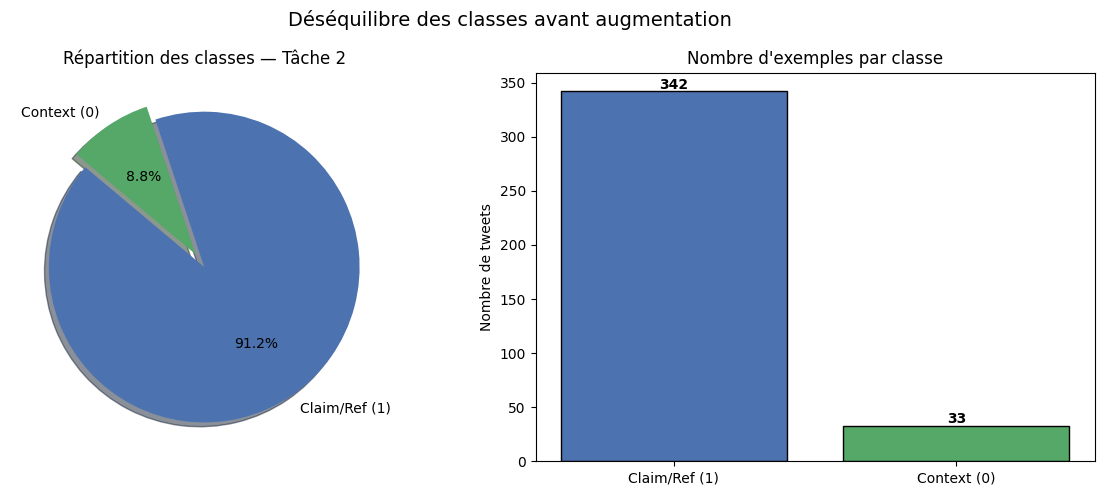

Ratio déséquilibre : 10x plus de Claim/Ref que de Context


In [ ]:
class_counts = df_sci['target'].value_counts()
labels = ['Claim/Ref (1)', 'Context (0)']
sizes = [class_counts[1], class_counts[0]]
colors = ['#4c72b0', '#55a868']
explode = (0, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=140)
axes[0].set_title("Répartition des classes — Tâche 2")

# Barplot avec valeurs
axes[1].bar(labels, sizes, color=colors, edgecolor='black')
axes[1].set_title("Nombre d'exemples par classe")
axes[1].set_ylabel("Nombre de tweets")
for i, v in enumerate(sizes):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.suptitle("Déséquilibre des classes avant augmentation", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Ratio déséquilibre : {sizes[0]//sizes[1]}x plus de Claim/Ref que de Context")

##**Augmentation des données**

Génération de nouveaux tweets Context par substitution de synonymes via WordNet (nltk). Pour chaque tweet Context original, 9 variantes sont créées en remplaçant aléatoirement 2 mots par leurs synonymes. Le nombre de tweets Context passe de 33 à 330.*texte en italique*

In [ ]:

def get_synonyms(word):
    """Retourne les synonymes d'un mot via WordNet"""
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            if lemma.name() != word and '_' not in lemma.name():
                synonyms.add(lemma.name())
    return list(synonyms)

def augment_by_synonym(text, n_augments=2):
    """Génère n_augments nouvelles phrases en remplaçant des mots par leurs synonymes"""
    words = text.split()
    augmented = []
    for _ in range(n_augments):
        new_words = words.copy()
        indices = np.random.choice(len(words), min(2, len(words)), replace=False)
        for idx in indices:
            syns = get_synonyms(words[idx])
            if syns:
                new_words[idx] = np.random.choice(syns)
        augmented.append(' '.join(new_words))
    return augmented

context_tweets = df_sci[df_sci['target'] == 0]['Tweet'].tolist()

print(f"Tweets Context originaux : {len(context_tweets)}")

np.random.seed(42)
new_tweets = []
for tweet in context_tweets:
    augmented = augment_by_synonym(tweet, n_augments=9)
    new_tweets.extend(augmented)

print(f"Tweets Context générés : {len(new_tweets)}")

df_augmented_context = pd.DataFrame({
    'Tweet': new_tweets,
    'target': 0
})

df_sci_augmented = pd.concat([
    df_sci[['Tweet', 'target']],
    df_augmented_context
], ignore_index=True)

print(f"\nRépartition après augmentation :")
print(df_sci_augmented['target'].value_counts())

Tweets Context originaux : 33
Tweets Context générés : 297

Répartition après augmentation :
target
1    342
0    330
Name: count, dtype: int64


##**Comparaison avant/après augmentation**

Visualisation de l'impact de l'augmentation sur la répartition des classes. Avant : 342 vs 33. Après : 342 vs 330 — répartition quasi équilibrée. Un exemple concret de tweet augmenté est affiché pour illustrer la méthode.



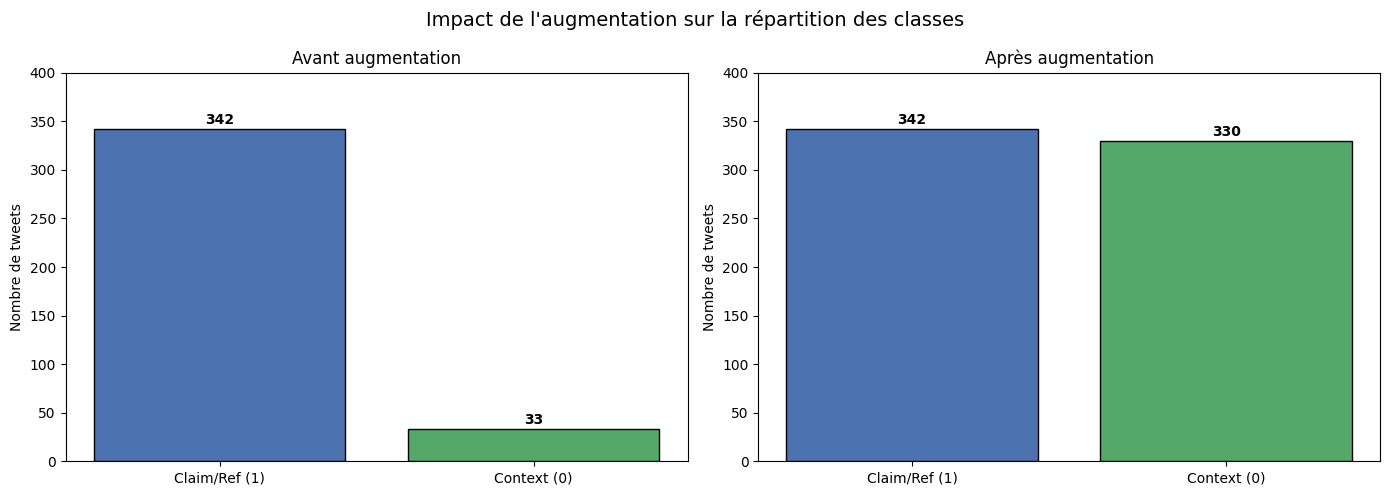

=== Exemple d'augmentation ===
Original  : @RepCohen @SenAlexander @SenBobCorker pls support #NIH funding to help fight #pancreaticcancer @PanCAN @PanCANMemphis #ifight4MyDad
Augmenté 1: @RepCohen @SenAlexander @SenBobCorker pls support #NIH funding to help fight #pancreaticcancer @PanCAN @PanCANMemphis #ifight4MyDad
Augmenté 2: @RepCohen @SenAlexander @SenBobCorker pls support #NIH funding to help fight #pancreaticcancer @PanCAN @PanCANMemphis #ifight4MyDad


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4c72b0', '#55a868']
labels = ['Claim/Ref (1)', 'Context (0)']

avant = [342, 33]
axes[0].bar(labels, avant, color=colors, edgecolor='black')
axes[0].set_title("Avant augmentation")
axes[0].set_ylabel("Nombre de tweets")
axes[0].set_ylim(0, 400)
for i, v in enumerate(avant):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

apres = df_sci_augmented['target'].value_counts().sort_index(ascending=False).values
axes[1].bar(labels, apres, color=colors, edgecolor='black')
axes[1].set_title("Après augmentation")
axes[1].set_ylabel("Nombre de tweets")
axes[1].set_ylim(0, 400)
for i, v in enumerate(apres):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle("Impact de l'augmentation sur la répartition des classes", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Exemple d'augmentation ===")
print(f"Original  : {context_tweets[0]}")
print(f"Augmenté 1: {augment_by_synonym(context_tweets[0], n_augments=1)[0]}")
print(f"Augmenté 2: {augment_by_synonym(context_tweets[0], n_augments=1)[0]}")

##**Wordcloud TF-IDF**

Visualisation des mots les plus fréquents dans chaque classe sous forme de nuages de mots.

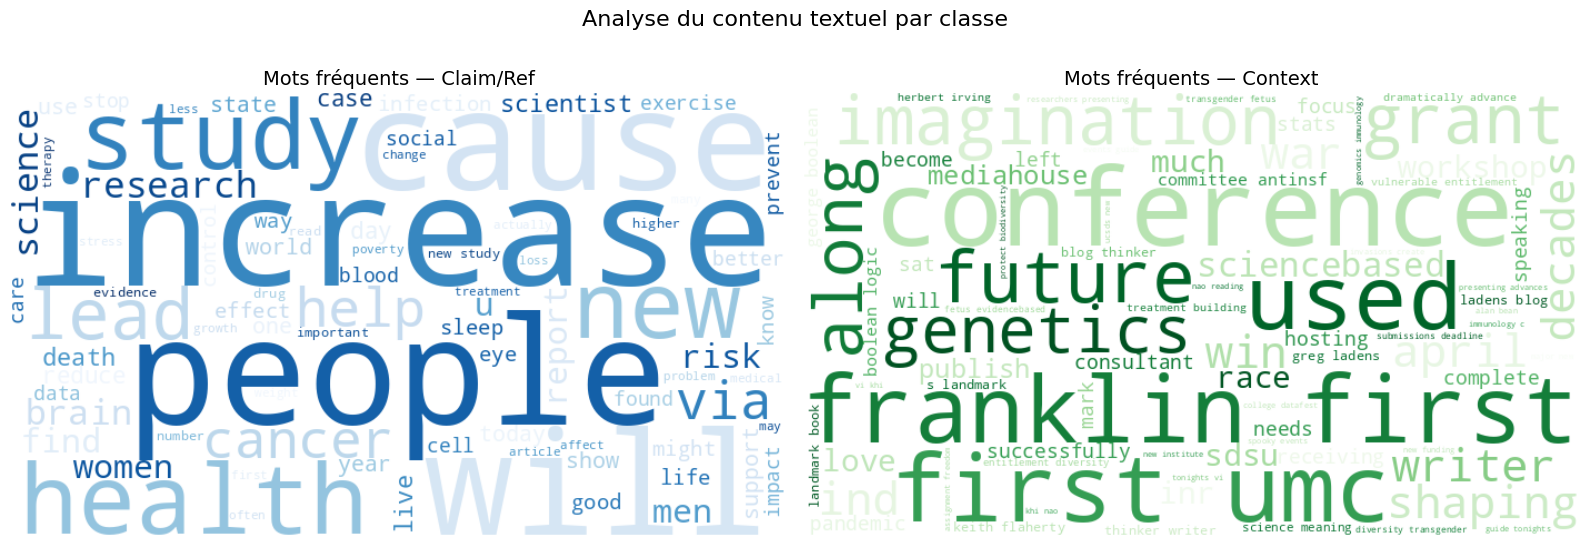

In [ ]:
def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"#\w+|@\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text.strip()

text_claimref = " ".join(df_sci_augmented[df_sci_augmented['target'] == 1]['Tweet'].apply(simple_clean))
text_context  = " ".join(df_sci_augmented[df_sci_augmented['target'] == 0]['Tweet'].apply(simple_clean))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_claimref = WordCloud(width=700, height=400,
                         background_color='white',
                         colormap='Blues',
                         max_words=80).generate(text_claimref)
axes[0].imshow(wc_claimref, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Mots fréquents — Claim/Ref", fontsize=14)

wc_context = WordCloud(width=700, height=400,
                        background_color='white',
                        colormap='Greens',
                        max_words=80).generate(text_context)
axes[1].imshow(wc_context, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Mots fréquents — Context", fontsize=14)

plt.suptitle("Analyse du contenu textuel par classe", fontsize=16)
plt.tight_layout()
plt.show()

##**Nettoyage + TF-IDF**

Application du TextNormalizer (minuscules, stop words, lemmatisation) sur les données originales. Vectorisation par TF-IDF (1500 features, bigrammes). Cette étape transforme les tweets en vecteurs numériques exploitables par les modèles.

In [ ]:
nltk.download('punkt_tab')
X = df_sci['Tweet']
y = df_sci['target']

normalizer = TextNormalizer(lowercase=True,
                            removestopwords=True,
                            getlemmatisation=True,
                            removedigit=True)

X_cleaned = normalizer.fit_transform(X)

print("Tweet original :", X.iloc[0])
print("Tweet nettoyé :", X_cleaned[0])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tweet original : Can any Gynecologist with Cancer Experience explain the dangers of Transvaginal Douching with Fluoride or other toxins such as Dioxin? #PDX
Tweet nettoyé : gynecologist cancer experience explain danger transvaginal douching fluoride toxin dioxin pdx


In [ ]:
vectorizer = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))

X_tfidf = vectorizer.fit_transform(X_cleaned)

print("Nombre de tweets :", X_tfidf.shape[0])
print("Nombre de mots transformés en colonnes :", X_tfidf.shape[1])

Nombre de tweets : 375
Nombre de mots transformés en colonnes : 1500


##**Split + 6 méthodes de sampling + Comparaison brut vs nettoyé**

Le split train/test est réalisé AVANT toute augmentation pour éviter le data leakage. Deux jeux de données sont comparés (brut et nettoyé) avec 6 méthodes de rééchantillonnage :
- Original (sans modification)
- Upsampling de la classe minoritaire
- Downsampling de la classe majoritaire
- Combiné (up + down)
- Up+Down équilibré
- Class Weight

La méthode Upsampling sur données nettoyées est retenue pour la suite.

=== Split sur données originales ===
Train : {1: 274, 0: 26}
Test  : {1: 68, 0: 7}

=== Top 15 — Tableau comparatif ===


,Données,Sampling,Modèle,Accuracy,F1 macro,Temps (s)
33,Nettoyé,Class Weight,SVM,0.907,0.705,0.00
21,Nettoyé,Upsampling,SVM,0.907,0.705,0.00
27,Nettoyé,Combiné,SVM,0.907,0.705,0.00
0,Brut,Original,SVM,0.933,0.704,0.01
28,Nettoyé,Combiné,Logistic Regression,0.893,0.685,0.03
34,Nettoyé,Class Weight,Logistic Regression,0.880,0.667,0.01
22,Nettoyé,Upsampling,Logistic Regression,0.880,0.667,0.01
3,Brut,Upsampling,SVM,0.907,0.657,0.02
15,Brut,Class Weight,SVM,0.907,0.657,0.00
9,Brut,Combiné,SVM,0.907,0.657,0.00


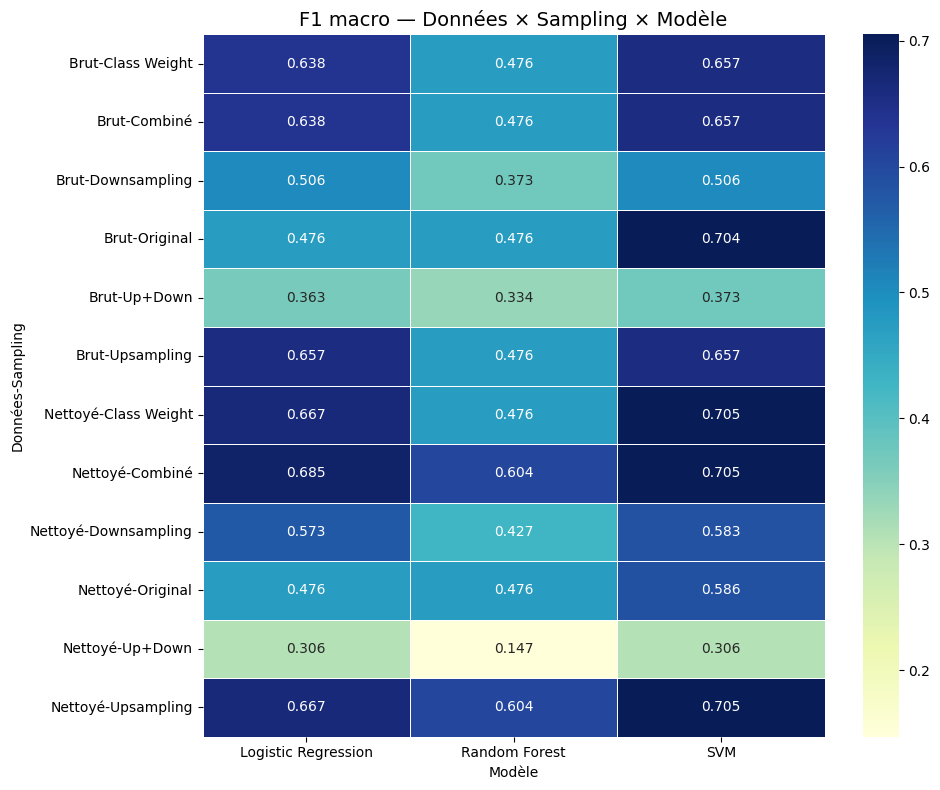

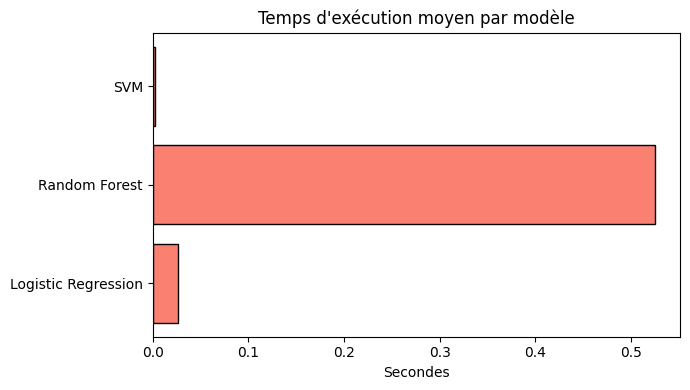


Méthode retenue : Upsampling + données nettoyées
Train : {1: 274, 0: 274}
Test  : {1: 68, 0: 7}


In [ ]:
# Nettoyage sur données ORIGINALES
normalizer_s8 = TextNormalizer(lowercase=True, removestopwords=True,
                                getlemmatisation=True, removedigit=True)
X_s8_cleaned = normalizer_s8.fit_transform(df_sci['Tweet'])
y_s8 = df_sci['target'].values

# Split sur données originales
idx = np.arange(len(y_s8))
idx_tr, idx_te, y_tr_s8, y_te_s8 = train_test_split(
    idx, y_s8, test_size=0.2, random_state=42, stratify=y_s8
)

X_tr_text = [X_s8_cleaned[i] for i in idx_tr]
X_te_text = [X_s8_cleaned[i] for i in idx_te]

print("=== Split sur données originales ===")
print(f"Train : {pd.Series(y_tr_s8).value_counts().to_dict()}")
print(f"Test  : {pd.Series(y_te_s8).value_counts().to_dict()}")

# Vectorisation données nettoyées (fit sur train uniquement)
vectorizer_s8 = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_tr_vec = vectorizer_s8.fit_transform(X_tr_text)
X_te_vec = vectorizer_s8.transform(X_te_text)

# Vectorisation données BRUTES (pas de nettoyage)
vectorizer_brut = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_tr_brut = vectorizer_brut.fit_transform([df_sci['Tweet'].values[i] for i in idx_tr])
X_te_brut = vectorizer_brut.transform([df_sci['Tweet'].values[i] for i in idx_te])

datasets = {
    "Brut":    (X_tr_brut.toarray(), X_te_brut, y_tr_s8),
    "Nettoyé": (X_tr_vec.toarray(),  X_te_vec,  y_tr_s8)
}

# Définition des 6 méthodes de sampling
def get_sampling_methods(X_arr, y_arr):
    mask_0 = y_arr == 0
    mask_1 = y_arr == 1
    n_min = mask_0.sum()
    n_maj = mask_1.sum()
    n_mid = (n_min + n_maj) // 2
    methods = {}

    # Original
    methods['Original'] = (sp.csr_matrix(X_arr), y_arr)

    # Upsampling
    X_up, y_up = resample(X_arr[mask_0], y_arr[mask_0],
                          replace=True, n_samples=n_maj, random_state=42)
    methods['Upsampling'] = (sp.csr_matrix(np.vstack([X_arr[mask_1], X_up])),
                             np.concatenate([y_arr[mask_1], y_up]))

    # Downsampling
    X_down, y_down = resample(X_arr[mask_1], y_arr[mask_1],
                              replace=False, n_samples=n_min, random_state=42)
    methods['Downsampling'] = (sp.csr_matrix(np.vstack([X_down, X_arr[mask_0]])),
                               np.concatenate([y_down, y_arr[mask_0]]))

    # Combiné
    X_min_c, y_min_c = resample(X_arr[mask_0], y_arr[mask_0],
                                replace=True, n_samples=n_mid, random_state=42)
    X_maj_c, y_maj_c = resample(X_arr[mask_1], y_arr[mask_1],
                                replace=False, n_samples=n_mid, random_state=42)
    methods['Combiné'] = (sp.csr_matrix(np.vstack([X_maj_c, X_min_c])),
                          np.concatenate([y_maj_c, y_min_c]))

    # Up + Down équilibré
    X_min_ud, y_min_ud = resample(X_arr[mask_0], y_arr[mask_0],
                                  replace=True, n_samples=n_maj, random_state=42)
    df_ud = pd.DataFrame(np.vstack([X_arr[mask_1], X_min_ud]))
    df_ud = resample(df_ud, replace=False, n_samples=2*n_min, random_state=42)
    methods['Up+Down'] = (sp.csr_matrix(df_ud.values),
                          np.array([1]*n_min + [0]*n_min))

    # Class Weight
    methods['Class Weight'] = (sp.csr_matrix(X_arr), y_arr)

    return methods

# Entraînement et évaluation
results_sampling = []
model_names = ["SVM", "Logistic Regression", "Random Forest"]

for data_name, (X_arr, X_te, y_tr) in datasets.items():
    sampling_methods = get_sampling_methods(X_arr, y_tr)

    for method_name, (X_sam, y_sam) in sampling_methods.items():
        for model_name in model_names:

            if model_name == "SVM":
                model = LinearSVC(class_weight='balanced' if method_name == 'Class Weight' else None,
                                  max_iter=1000)
            elif model_name == "Logistic Regression":
                model = LogisticRegression(
                    class_weight='balanced' if method_name == 'Class Weight' else None,
                    max_iter=1000, random_state=42)
            else:
                model = RandomForestClassifier(
                    n_estimators=100, random_state=42,
                    class_weight='balanced' if method_name == 'Class Weight' else None)

            start = time.time()
            model.fit(X_sam, y_sam)
            elapsed = round(time.time() - start, 2)

            y_pred = model.predict(X_te)
            acc = round(accuracy_score(y_te_s8, y_pred), 3)
            f1  = round(f1_score(y_te_s8, y_pred, average='macro'), 3)

            results_sampling.append({
                'Données':   data_name,
                'Sampling':  method_name,
                'Modèle':    model_name,
                'Accuracy':  acc,
                'F1 macro':  f1,
                'Temps (s)': elapsed
            })

df_sampling = pd.DataFrame(results_sampling)

print("\n=== Top 15 — Tableau comparatif ===")
display(df_sampling.sort_values("F1 macro", ascending=False).head(15))

# Heatmap
pivot = df_sampling.pivot_table(
    index=['Données', 'Sampling'],
    columns='Modèle',
    values='F1 macro'
)
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title("F1 macro — Données × Sampling × Modèle", fontsize=14)
plt.tight_layout()
plt.show()

# Barplot temps d'exécution
df_temps = df_sampling.groupby('Modèle')['Temps (s)'].mean().reset_index()
plt.figure(figsize=(7, 4))
plt.barh(df_temps['Modèle'], df_temps['Temps (s)'], color='salmon', edgecolor='black')
plt.title("Temps d'exécution moyen par modèle")
plt.xlabel("Secondes")
plt.tight_layout()
plt.show()

# On retient Upsampling + Nettoyé pour la suite
X_train_bal = get_sampling_methods(X_tr_vec.toarray(), y_tr_s8)['Upsampling'][0]
y_train_bal = get_sampling_methods(X_tr_vec.toarray(), y_tr_s8)['Upsampling'][1]
X_test = X_te_vec
y_test = y_te_s8

print("\nMéthode retenue : Upsampling + données nettoyées")
print(f"Train : {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Test  : {pd.Series(y_test).value_counts().to_dict()}")

##**Modèles de base**


Modèle : Naive Bayes
  CV 10 folds F1 macro : 0.477 | Temps : 0.07s
              precision    recall  f1-score   support

     Context       0.25      0.71      0.37         7
   Claim/Ref       0.96      0.78      0.86        68

    accuracy                           0.77        75
   macro avg       0.61      0.75      0.62        75
weighted avg       0.90      0.77      0.82        75



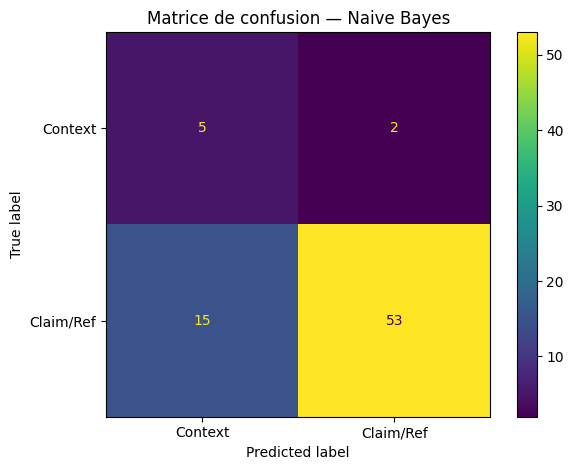


Modèle : SVM
  CV 10 folds F1 macro : 0.613 | Temps : 0.21s
              precision    recall  f1-score   support

     Context       0.50      0.43      0.46         7
   Claim/Ref       0.94      0.96      0.95        68

    accuracy                           0.91        75
   macro avg       0.72      0.69      0.71        75
weighted avg       0.90      0.91      0.90        75



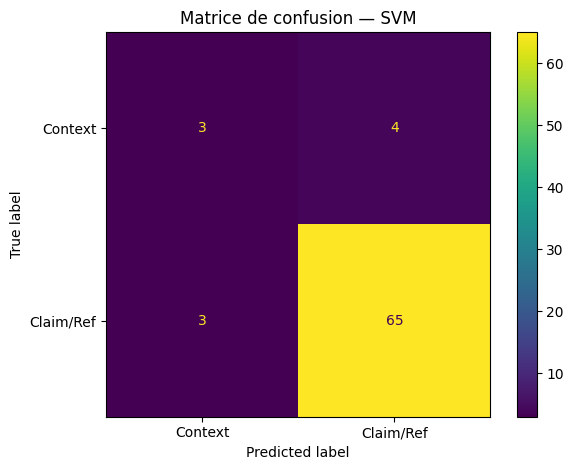


Modèle : Random Forest
  CV 10 folds F1 macro : 0.477 | Temps : 10.6s
              precision    recall  f1-score   support

     Context       1.00      0.14      0.25         7
   Claim/Ref       0.92      1.00      0.96        68

    accuracy                           0.92        75
   macro avg       0.96      0.57      0.60        75
weighted avg       0.93      0.92      0.89        75



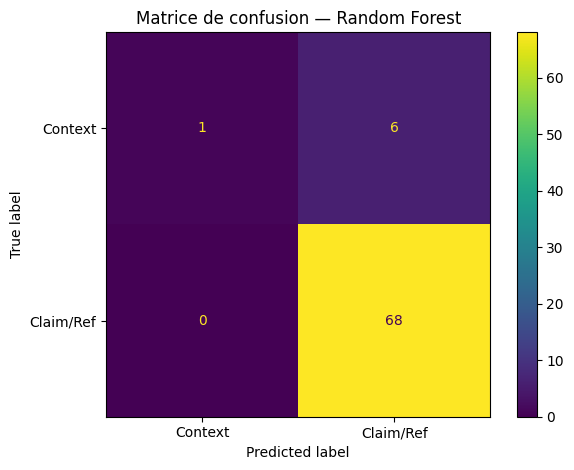


Modèle : Logistic Regression
  CV 10 folds F1 macro : 0.665 | Temps : 0.29s
              precision    recall  f1-score   support

     Context       0.38      0.43      0.40         7
   Claim/Ref       0.94      0.93      0.93        68

    accuracy                           0.88        75
   macro avg       0.66      0.68      0.67        75
weighted avg       0.89      0.88      0.88        75



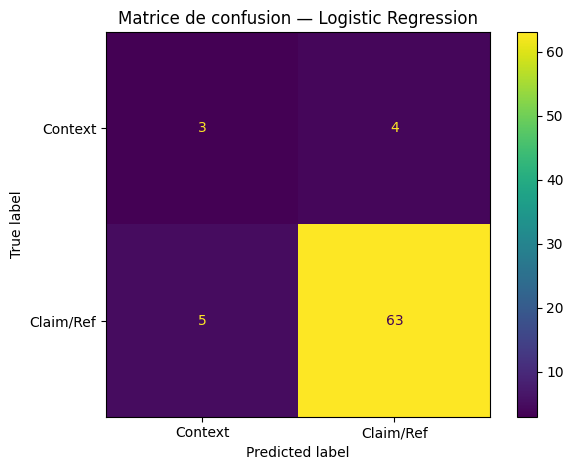


Modèle : Gradient Boosting
  CV 10 folds F1 macro : 0.600 | Temps : 7.53s
              precision    recall  f1-score   support

     Context       0.33      0.57      0.42         7
   Claim/Ref       0.95      0.88      0.92        68

    accuracy                           0.85        75
   macro avg       0.64      0.73      0.67        75
weighted avg       0.89      0.85      0.87        75



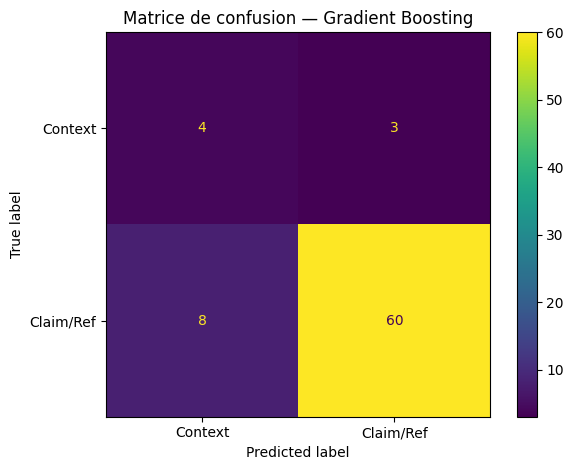


=== Tableau comparatif des modèles ===
                     F1 macro  F1 macro CV  F1 class 0 (Context)  \
SVM                     0.705        0.613                 0.462   
Gradient Boosting       0.669        0.600                 0.421   
Logistic Regression     0.667        0.665                 0.400   
Naive Bayes             0.616        0.477                 0.370   
Random Forest           0.604        0.477                 0.250   

                     F1 class 1 (Claim/Ref)  Accuracy  Temps (s)  
SVM                                   0.949     0.907       0.21  
Gradient Boosting                     0.916     0.853       7.53  
Logistic Regression                   0.933     0.880       0.29  
Naive Bayes                           0.862     0.773       0.07  
Random Forest                         0.958     0.920      10.60  


In [ ]:
models = {
    "Naive Bayes":         MultinomialNB(),
    "SVM":                 LinearSVC(class_weight='balanced', max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    start_time = time.time()

    # Cross-validation 10 folds sur données originales
    fold_f1_scores = []
    for train_idx, test_idx in skf.split(X_tr_vec, y_tr_s8):
        X_fold_train = X_tr_vec[train_idx]
        X_fold_test  = X_tr_vec[test_idx]
        y_fold_train = y_tr_s8[train_idx]
        y_fold_test  = y_tr_s8[test_idx]
        model.fit(X_fold_train, y_fold_train)
        y_fold_pred = model.predict(X_fold_test)
        fold_f1_scores.append(f1_score(y_fold_test, y_fold_pred, average='macro'))

    elapsed = round(time.time() - start_time, 2)

    # Évaluation finale sur le test
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "F1 macro":               round(report['macro avg']['f1-score'], 3),
        "F1 macro CV":            round(np.mean(fold_f1_scores), 3),
        "F1 class 0 (Context)":   round(report['0']['f1-score'], 3),
        "F1 class 1 (Claim/Ref)": round(report['1']['f1-score'], 3),
        "Accuracy":               round(report['accuracy'], 3),
        "Temps (s)":              elapsed
    }

    print(f"\n{'='*40}")
    print(f"Modèle : {name}")
    print(f"  CV 10 folds F1 macro : {np.mean(fold_f1_scores):.3f} | Temps : {elapsed}s")
    print(classification_report(y_test, y_pred, target_names=["Context", "Claim/Ref"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Context", "Claim/Ref"])
    disp.plot()
    plt.title(f"Matrice de confusion — {name}")
    plt.tight_layout()
    plt.show()

print("\n=== Tableau comparatif des modèles ===")
df_results = pd.DataFrame(results).T
print(df_results.sort_values("F1 macro", ascending=False))

## Visualisations comparatives
Trois visualisations complémentaires :
- Barplot : F1 macro test vs cross-validation pour chaque modèle
- Heatmap : toutes les métriques (F1 macro, F1 Context, F1 Claim/Ref, Accuracy) par modèle
- Courbes ROC : comparaison des AUC pour SVM, Random Forest, Logistic Regression et Gradient Boosting

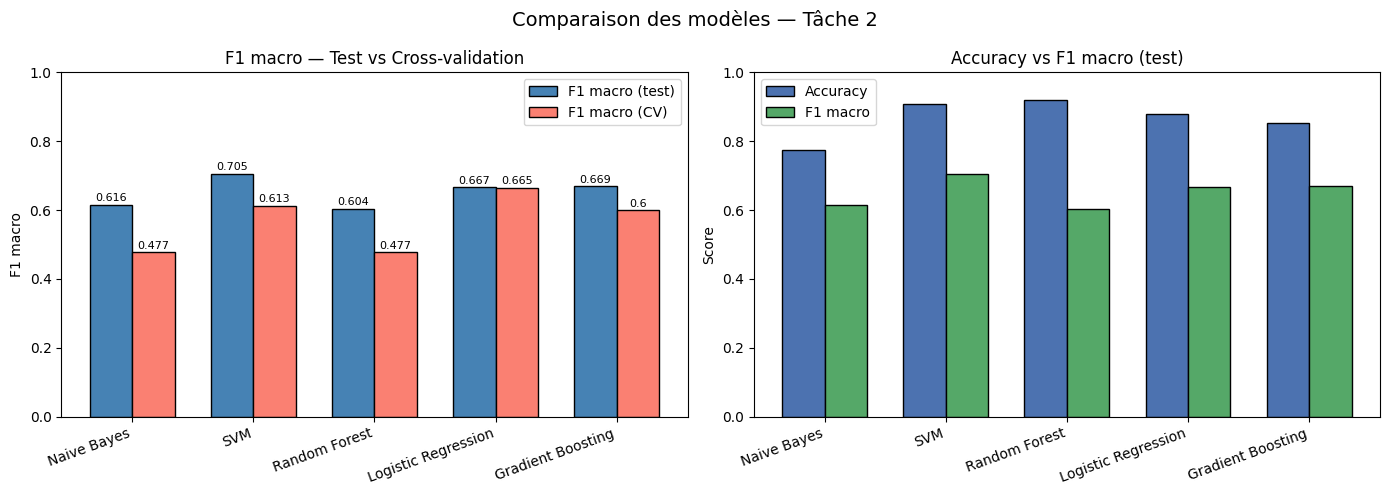

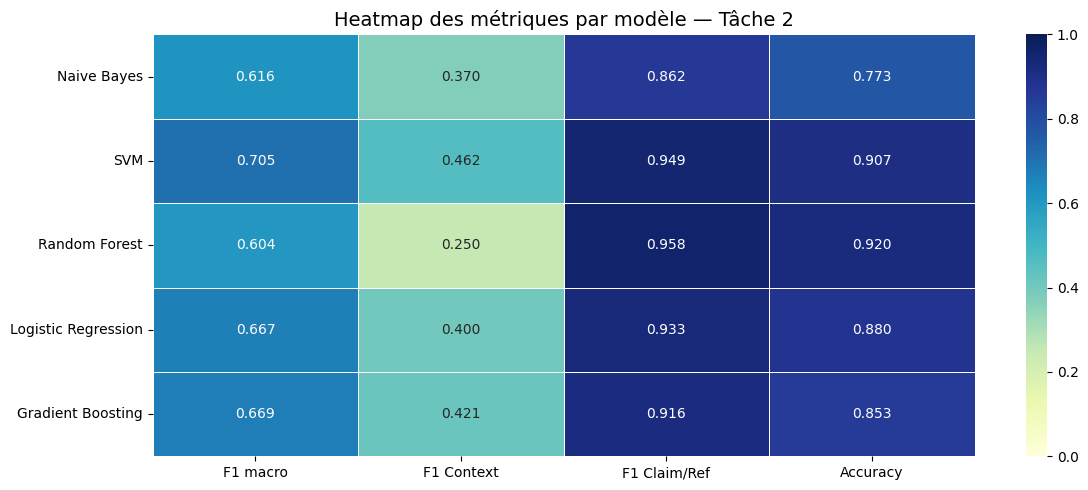

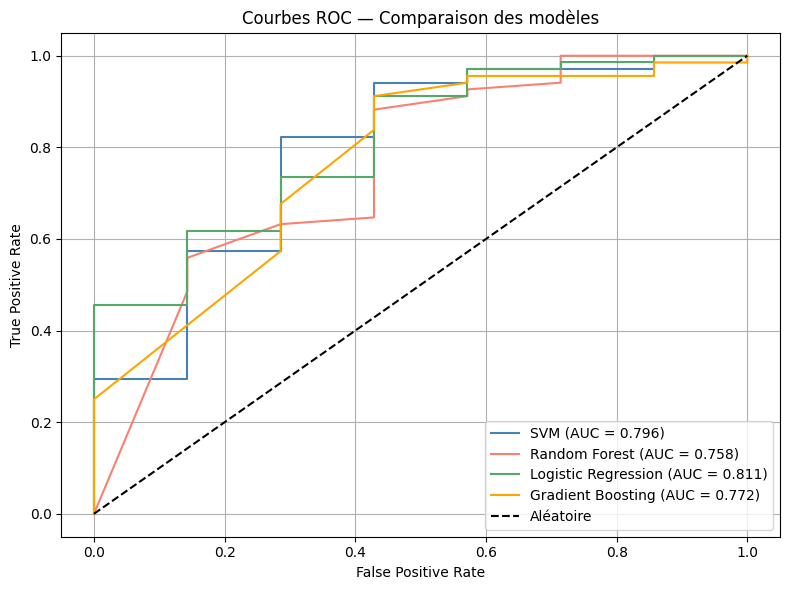

In [ ]:
# --- Barplot comparatif F1 macro vs Accuracy ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modeles = list(results.keys())
f1_test    = [results[m]['F1 macro'] for m in modeles]
acc_test   = [results[m]['Accuracy'] for m in modeles]
f1_cv = [results[m]['F1 macro CV'] for m in modeles]
x = np.arange(len(modeles))
width = 0.35

# F1 macro : test vs CV
axes[0].bar(x - width/2, f1_test, width, label='F1 macro (test)', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, f1_cv,   width, label='F1 macro (CV)',   color='salmon',    edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modeles, rotation=20, ha='right')
axes[0].set_ylim(0, 1)
axes[0].set_title("F1 macro — Test vs Cross-validation")
axes[0].set_ylabel("F1 macro")
axes[0].legend()
for i, (v1, v2) in enumerate(zip(f1_test, f1_cv)):
    axes[0].text(i - width/2, v1 + 0.01, str(v1), ha='center', fontsize=8)
    axes[0].text(i + width/2, v2 + 0.01, str(v2), ha='center', fontsize=8)

# Accuracy vs F1 macro sur le test
axes[1].bar(x - width/2, acc_test, width, label='Accuracy', color='#4c72b0', edgecolor='black')
axes[1].bar(x + width/2, f1_test,  width, label='F1 macro', color='#55a868', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modeles, rotation=20, ha='right')
axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy vs F1 macro (test)")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.suptitle("Comparaison des modèles — Tâche 2", fontsize=14)
plt.tight_layout()
plt.show()

# --- Heatmap des métriques ---
metrics_data = {
    'F1 macro':       [results[m]['F1 macro'] for m in modeles],
    'F1 Context':     [results[m]['F1 class 0 (Context)'] for m in modeles],
    'F1 Claim/Ref':   [results[m]['F1 class 1 (Claim/Ref)'] for m in modeles],
    'Accuracy':       [results[m]['Accuracy'] for m in modeles],
}

df_heatmap = pd.DataFrame(metrics_data, index=modeles)

plt.figure(figsize=(12, 5))
sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, vmin=0, vmax=1)
plt.title("Heatmap des métriques par modèle — Tâche 2", fontsize=14)
plt.tight_layout()
plt.show()

# --- Courbes ROC pour tous les modèles ---
models_roc = {
    "SVM":                 SVC(kernel='linear', class_weight='balanced', probability=True),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

plt.figure(figsize=(8, 6))
colors_roc = ['steelblue', 'salmon', '#55a868', 'orange']

for (name, model), color in zip(models_roc.items(), colors_roc):
    model.fit(X_train_bal, y_train_bal)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC — Comparaison des modèles')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

##**Recherche hyperparamètres (Optuna)**

In [ ]:
model_names = [
    "Naive Bayes",
    "SVM",
    "Random Forest",
    "Logistic Regression",
    "Gradient Boosting"
]

best_params = {}

for model_name in model_names:
    study = optuna.create_study(direction="maximize")
    study.optimize(
        lambda trial: objective(trial, model_name, X_tr_vec, y_tr_s8),
        n_trials=20
    )
    best_params[model_name] = study.best_params
    print(f"=== {model_name} ===")
    print(f"  Meilleur F1   : {study.best_value:.3f}")
    print(f"  Meilleurs params : {study.best_params}")
    print()

print("=== Récapitulatif des meilleurs hyperparamètres ===")
for model, params in best_params.items():
    print(f"{model} : {params}")

=== Naive Bayes ===
  Meilleur F1   : 0.954
  Meilleurs params : {'alpha': 0.3948584918337084}

=== SVM ===
  Meilleur F1   : 0.959
  Meilleurs params : {'C': 0.21714410163294595}

=== Random Forest ===
  Meilleur F1   : 0.954
  Meilleurs params : {'n_estimators': 50, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 5}

=== Logistic Regression ===
  Meilleur F1   : 0.961
  Meilleurs params : {'C': 0.1975098719389086}

=== Gradient Boosting ===
  Meilleur F1   : 0.961
  Meilleurs params : {'n_estimators': 100, 'learning_rate': 0.07738957680345862, 'max_depth': 2, 'subsample': 0.6431725602491509}

=== Récapitulatif des meilleurs hyperparamètres ===
Naive Bayes : {'alpha': 0.3948584918337084}
SVM : {'C': 0.21714410163294595}
Random Forest : {'n_estimators': 50, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 5}
Logistic Regression : {'C': 0.1975098719389086}
Gradient Boosting : {'n_estimators': 100, 'learning_rate': 0.07738957680345862, 'max_depth': 2, 'subsample': 

##**Courbes d'apprentissage**

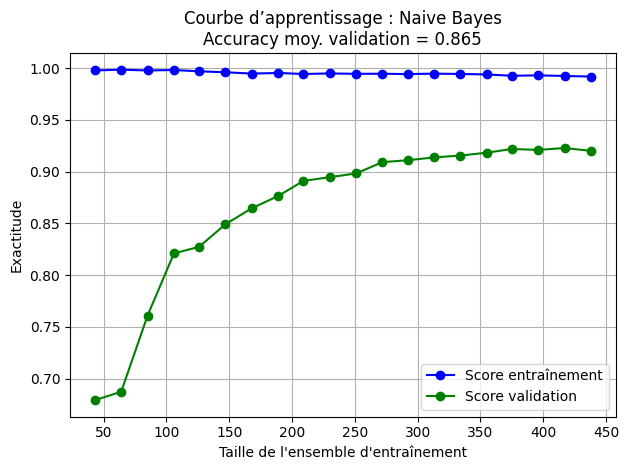

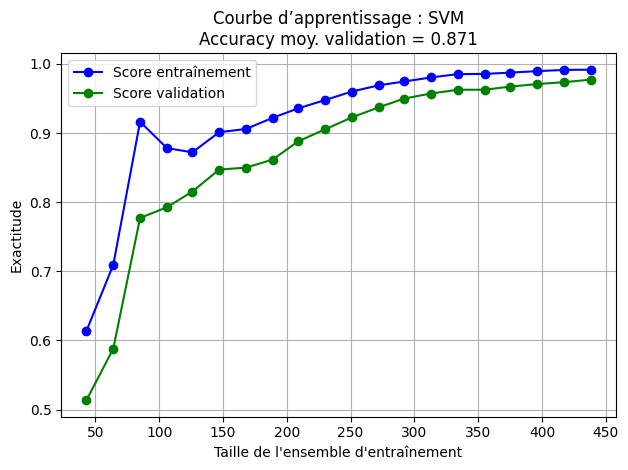

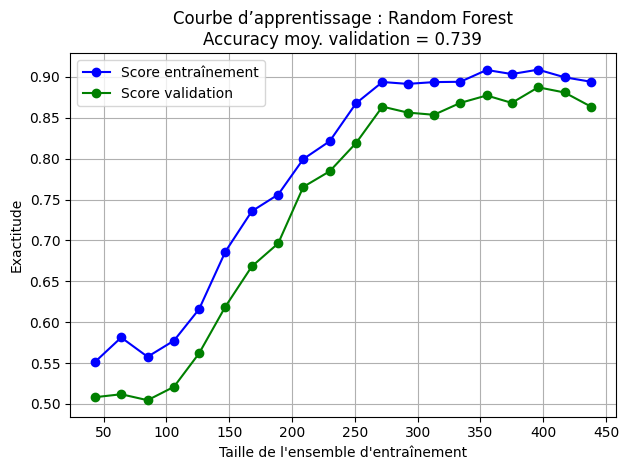

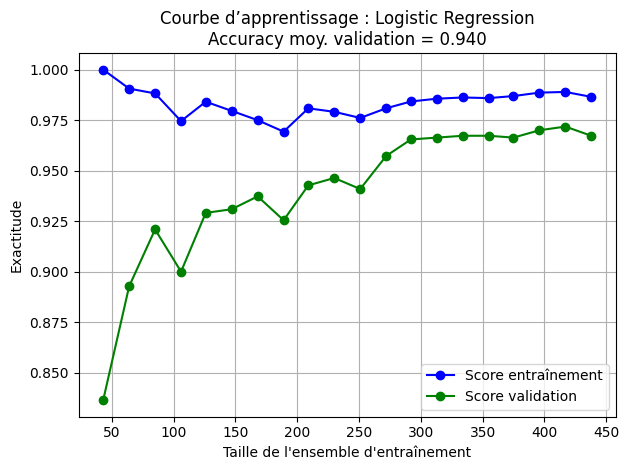

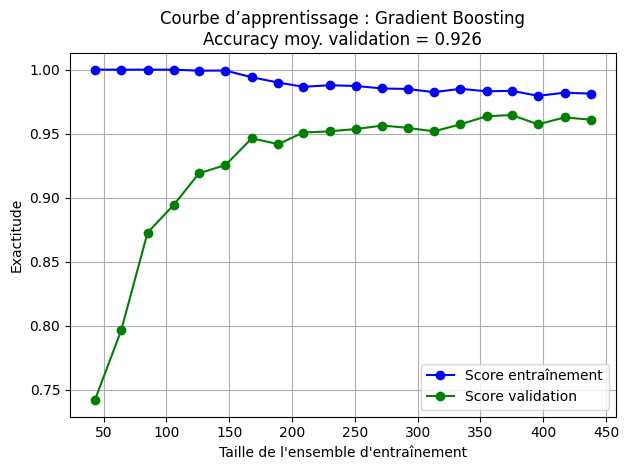

In [ ]:
models_optimized = {
    "Naive Bayes": MultinomialNB(
        alpha=best_params["Naive Bayes"]["alpha"]
    ),
    "SVM": SVC(
        C=best_params["SVM"]["C"],
        kernel='linear', class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=best_params["Random Forest"]["n_estimators"],
        max_depth=best_params["Random Forest"]["max_depth"],
        min_samples_split=best_params["Random Forest"]["min_samples_split"],
        min_samples_leaf=best_params["Random Forest"]["min_samples_leaf"],
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=best_params["Logistic Regression"]["C"],
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=best_params["Gradient Boosting"]["n_estimators"],
        learning_rate=best_params["Gradient Boosting"]["learning_rate"],
        max_depth=best_params["Gradient Boosting"]["max_depth"],
        subsample=best_params["Gradient Boosting"]["subsample"],
        random_state=42
    )
}

for name, model in models_optimized.items():
    plot_learning_curves(model, X_train_bal, y_train_bal, name)

 ## **Analyse des erreurs + Features discriminantes**

In [ ]:

best_model_final = LinearSVC(
    C=best_params["SVM"]["C"],
    class_weight='balanced', max_iter=1000
)
best_model_final.fit(X_train_bal, y_train_bal)
y_pred_final = best_model_final.predict(X_test)


tweets_original = [df_sci['Tweet'].values[i] for i in idx_te]

df_errors = pd.DataFrame({
    'Tweet': tweets_original,
    'true': y_te_s8,
    'predicted': y_pred_final
})

faux_negatifs = df_errors[(df_errors['true'] == 0) & (df_errors['predicted'] == 1)]
print(f"=== Faux négatifs — Context prédit comme Claim/Ref : {len(faux_negatifs)} tweet(s) ===")
for _, row in faux_negatifs.iterrows():
    print(f"  → {row['Tweet'][:150]}")

print()

faux_positifs = df_errors[(df_errors['true'] == 1) & (df_errors['predicted'] == 0)]
print(f"=== Faux positifs — Claim/Ref prédit comme Context : {len(faux_positifs)} tweet(s) ===")
for _, row in faux_positifs.iterrows():
    print(f"  → {row['Tweet'][:150]}")

=== Faux négatifs — Context prédit comme Claim/Ref : 4 tweet(s) ===
  → Freeman J. Dyson, a mathematical prodigy who left his mark on subatomic physics before gaining public renown as a writer and technological visionary, 
  → VIDEO: Dr. Keith Flaherty talks about the genetics of cancer, #targetedtherapy, #clinicaltrials, precision medicine https://t.co/oFjd4YEEZe
  → The Rise of bilingual #sciencejournalism #ECSJ2017 @jarimakinen @nuriajar @swaforini @fedkukso https://t.co/3P7gdyQUyb
  → @anshulkundaje @NipsConference Would love to see MLCB as a full conference, with workshops in genomics, immunology, &c.

=== Faux positifs — Claim/Ref prédit comme Context : 4 tweet(s) ===
  → .@LawrenceGostin wrote this 3 years ago in @JAMA_current Sadly even more relevant today 4 reforms to address mass shootings: 1. Dedicate federal fundi
  → Coping with levels of explanation in the behavioral sciences https://t.co/C2p0fms0iw
  → France: N. Mayer. “Bring the Poor Back In! Inequalities, Welfare and 

## **BONUS — Features discriminantes**

Identification des mots les plus discriminants pour chaque classe via les coefficients de la Logistic Regression. Context : vocabulaire institutionnel (science, funding, grant). Claim/Ref : vocabulaire d'affirmation causale (increase, brain, risk).

=== Top 15 mots — Claim/Ref (classe 1) ===
  increase                  coef = 0.649
  people                    coef = 0.605
  eurekamag                 coef = 0.520
  brain                     coef = 0.501
  change                    coef = 0.498
  life                      coef = 0.497
  lead                      coef = 0.474
  read                      coef = 0.471
  world                     coef = 0.451
  risk                      coef = 0.440
  drug                      coef = 0.438
  study                     coef = 0.434
  co vxh2gnrtrp             coef = 0.433
  way                       coef = 0.433
  state                     coef = 0.426

=== Top 15 mots — Context (classe 0) ===
  science                   coef = -3.195
  support                   coef = -2.552
  research                  coef = -2.209
  funding                   coef = -1.862
  lupus                     coef = -1.557
  institute                 coef = -1.470
  grant                     coef = -1.456
  base

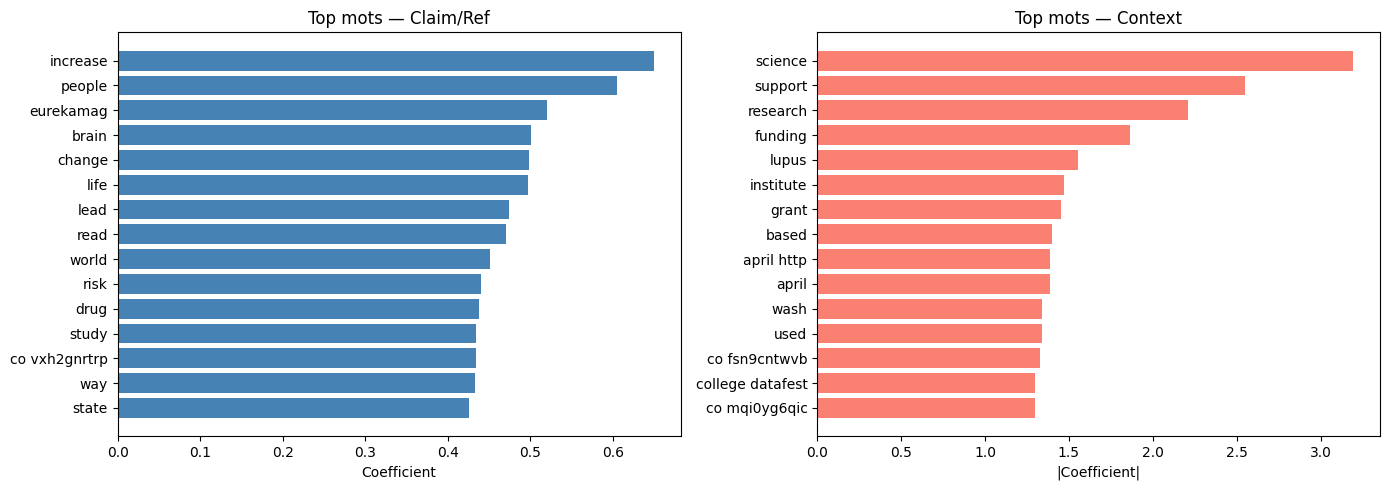

In [ ]:

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

feature_names = np.array(vectorizer_s8.get_feature_names_out())

coefficients = lr.coef_[0]

top_n = 15
top_claimref = np.argsort(coefficients)[-top_n:][::-1]
top_context  = np.argsort(coefficients)[:top_n]

print("=== Top 15 mots — Claim/Ref (classe 1) ===")
for i in top_claimref:
    print(f"  {feature_names[i]:<25} coef = {coefficients[i]:.3f}")

print("\n=== Top 15 mots — Context (classe 0) ===")
for i in top_context:
    print(f"  {feature_names[i]:<25} coef = {coefficients[i]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_claimref][::-1], coefficients[top_claimref][::-1], color='steelblue')
axes[0].set_title("Top mots — Claim/Ref")
axes[0].set_xlabel("Coefficient")

axes[1].barh(feature_names[top_context][::-1], np.abs(coefficients[top_context][::-1]), color='salmon')
axes[1].set_title("Top mots — Context")
axes[1].set_xlabel("|Coefficient|")

plt.tight_layout()
plt.show()

##**tableau de synthèse final**

In [ ]:
print("=== Synthèse finale : Tâche 2 — {CLAIM, REF} vs {CONTEXT} ===\n")

df_final = pd.DataFrame(results).T.sort_values("F1 macro", ascending=False)
print(df_final.to_string())

print("\n=== Conclusions ===")
print("""
1. SVM est le meilleur modèle (F1 macro = 0.705).
   Il obtient le meilleur équilibre entre les deux classes
   et la meilleure accuracy globale (0.907).

2. Random Forest est le moins adapté : F1 Context = 0.250,
   il prédit presque tout comme Claim/Ref malgré l'upsampling.

3. L'accuracy seule est trompeuse : Random Forest a 0.920 d'accuracy
   mais un F1 macro de seulement 0.604 — il ignore presque
   complètement la classe Context.

4. Le déséquilibre des classes (342 vs 33 originaux) est le défi
   principal. Malgré l'augmentation (330 Context) et l'upsampling
   (274 vs 274 en train), le test ne contient que 7 tweets Context
   originaux, ce qui limite l'évaluation réelle.

5. Les features discriminantes confirment la séparation lexicale :
   les tweets Context utilisent un vocabulaire institutionnel
   (science, funding, grant, institute) alors que les tweets
   Claim/Ref contiennent des mots d'affirmation causale
   (increase, risk, brain, prevent).

6. Limite principale : TF-IDF ne capture pas le sens global
   d'un tweet. Des tweets courts avec seulement des hashtags
   ou des liens sont difficiles à classifier correctement,
   comme le montrent les 8 erreurs de l'analyse des faux positifs/négatifs.
""")

=== Synthèse finale : Tâche 2 — {CLAIM, REF} vs {CONTEXT} ===

                     F1 macro  F1 macro CV  F1 class 0 (Context)  F1 class 1 (Claim/Ref)  Accuracy  Temps (s)
SVM                     0.705        0.613                 0.462                   0.949     0.907       0.21
Gradient Boosting       0.669        0.600                 0.421                   0.916     0.853       7.53
Logistic Regression     0.667        0.665                 0.400                   0.933     0.880       0.29
Naive Bayes             0.616        0.477                 0.370                   0.862     0.773       0.07
Random Forest           0.604        0.477                 0.250                   0.958     0.920      10.60

=== Conclusions ===

1. SVM est le meilleur modèle (F1 macro = 0.705).
   Il obtient le meilleur équilibre entre les deux classes
   et la meilleure accuracy globale (0.907).

2. Random Forest est le moins adapté : F1 Context = 0.250,
   il prédit presque tout comme Claim/Ref